# **Clustering & Dimensionality Reduction on Iris Dataset**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

# Load data
iris = load_iris()
X = iris.data
y = iris.target # For comparison only
df = pd.DataFrame(X, columns=iris.feature_names)

Section A: K-Means Clustering & Elbow Method

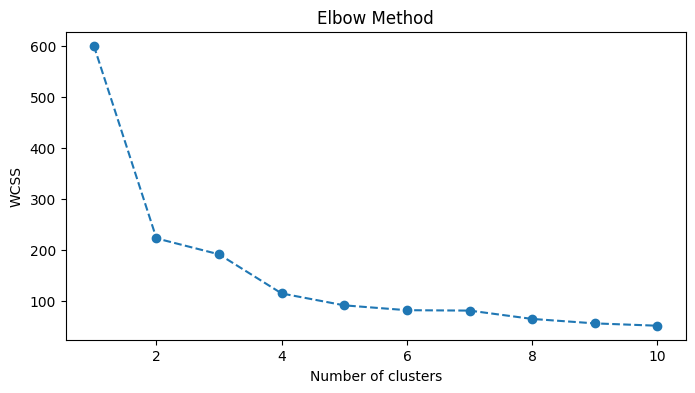

In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

Interpretation: The "elbow" typically appears at $k=3$. While $k=2$ shows a sharp drop, $k=3$ aligns with the actual biological species in the dataset.

In [3]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

df["KMeans_Cluster"] = kmeans_labels


2D Cluster Plot (First Two Features)

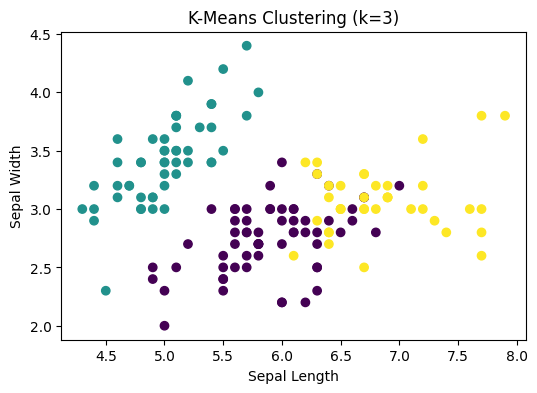

In [4]:
plt.figure(figsize=(6,4))
plt.scatter(X[:,0], X[:,1], c=kmeans_labels)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("K-Means Clustering (k=3)")
plt.show()


In [6]:
df["True_Label"] = y
pd.crosstab(df["True_Label"], df["KMeans_Cluster"])

KMeans_Cluster,0,1,2
True_Label,,,
0,0,50,0
1,48,0,2
2,14,0,36


In [8]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans_labels)

np.float64(0.5528190123564095)

Section B: Principal Component Analysis (PCA)

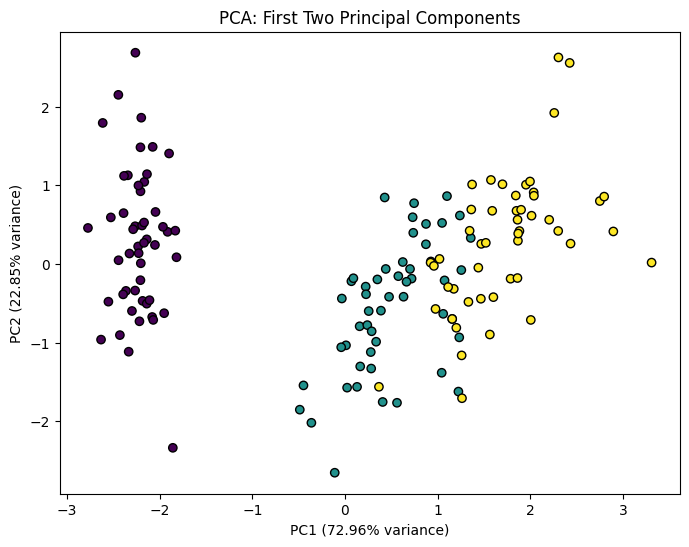

Total Explained Variance: 95.81%


In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k')
plt.title('PCA: First Two Principal Components')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.show()

print(f"Total Explained Variance: {np.sum(pca.explained_variance_ratio_):.2%}")

Clustering on PCA-reduced data often removes "noise" and focuses on the most significant variance, making the clusters (especially Versicolor and Virginica) slightly easier to separate than in raw 4D space.

Section C: Hierarchical Clustering

Dendrogram

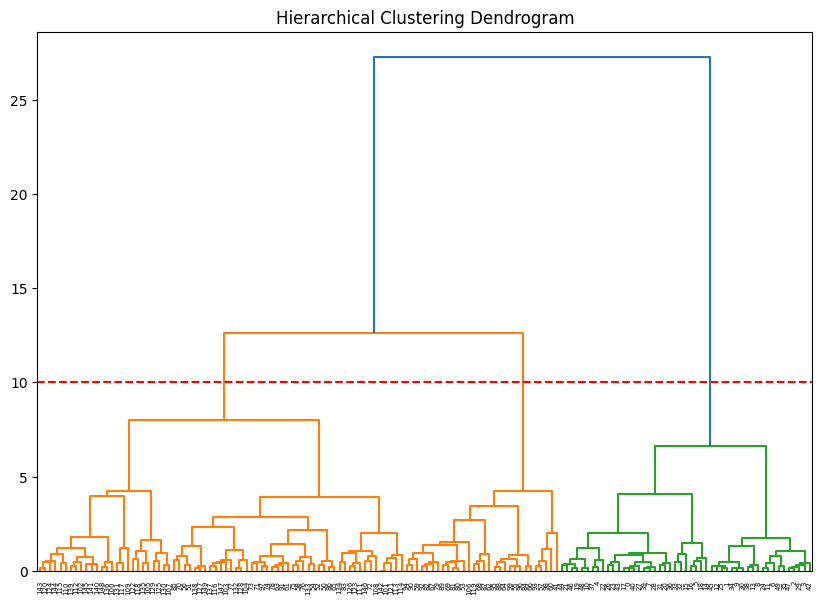

In [10]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.axhline(y=10, color='r', linestyle='--') # Theoretical cut-off for 3 clusters
plt.show()

Agglomerative Clustering

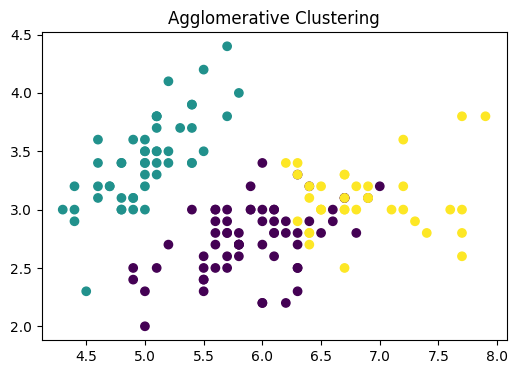

col_0,0,1,2
row_0,,,
0,62,0,2
1,0,50,0
2,0,0,36


In [12]:
agglo = AgglomerativeClustering(n_clusters=3)
agglo_labels = agglo.fit_predict(X)

plt.figure(figsize=(6,4))
plt.scatter(X[:,0], X[:,1], c=agglo_labels)
plt.title("Agglomerative Clustering")
plt.show()

pd.crosstab(agglo_labels, kmeans_labels)

Hierarchical clustering gives results very similar to K-Means.

Section D: DBSCAN

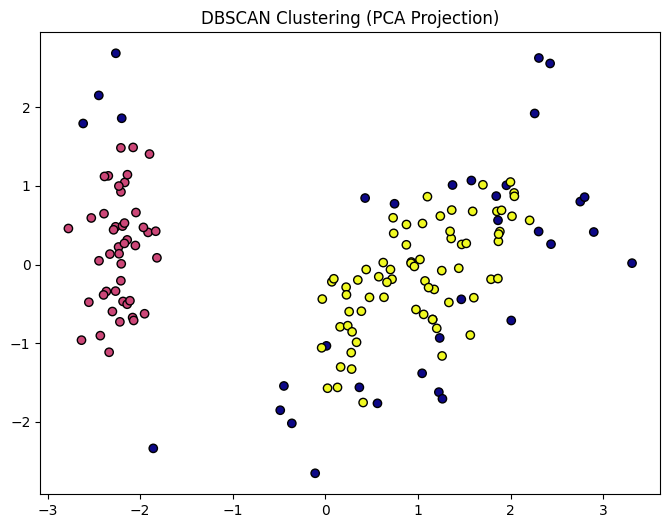

In [11]:
# Experimenting with eps (radius) and min_samples
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='plasma', edgecolor='k')
plt.title('DBSCAN Clustering (PCA Projection)')
plt.show()

Comparison:

K-Means: Forces every point into a cluster (spherical shapes).

DBSCAN: Can label points as -1 (noise). In Iris, DBSCAN often struggles to separate Versicolor and Virginica because they are physically very close (high density overlap), often merging them into one cluster while keeping Setosa separate.

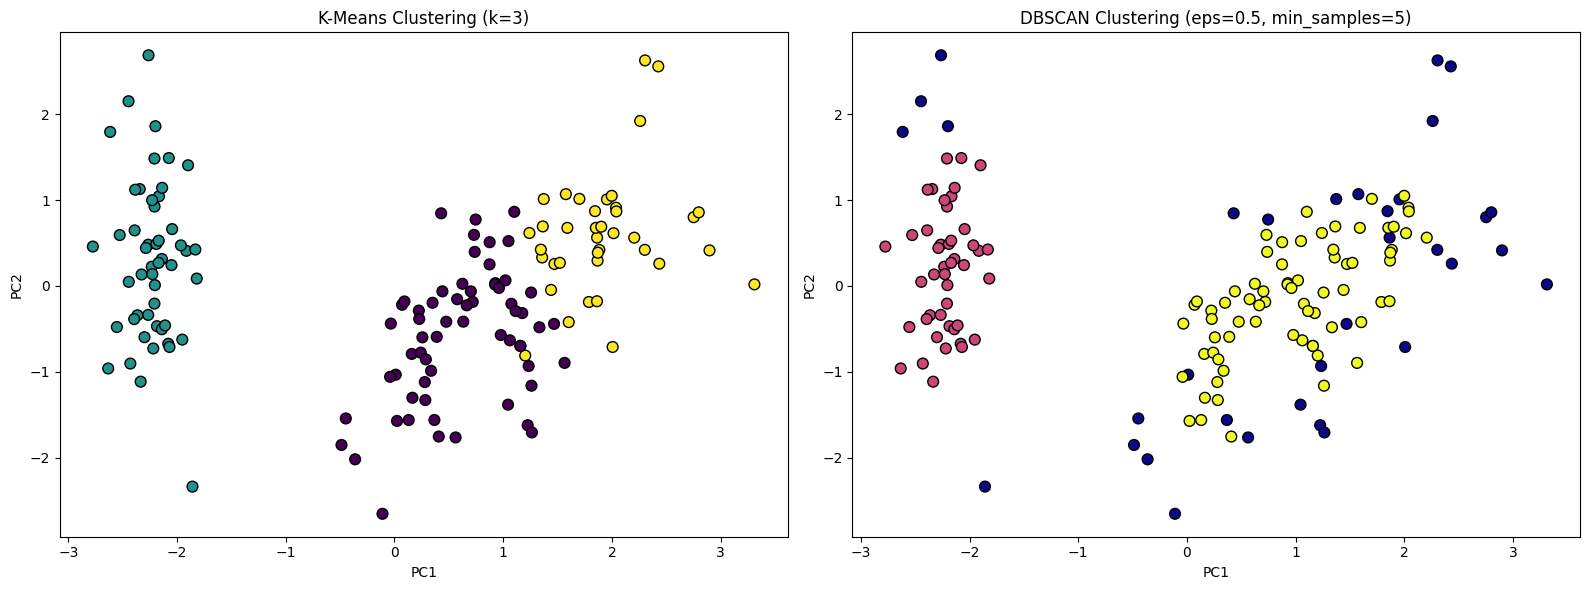

In [15]:
# Comparison Plot: K-Means vs DBSCAN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# K-Means Plot
ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', edgecolor='k', s=60)
ax1.set_title('K-Means Clustering (k=3)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')

# DBSCAN Plot
# Re-running DBSCAN to ensure it's in the same scope
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap='plasma', edgecolor='k', s=60)
ax2.set_title('DBSCAN Clustering (eps=0.5, min_samples=5)')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')

plt.tight_layout()
plt.show()

## Section E: Final Comparison & Summary

After implementing four different unsupervised learning techniques, we can compare their performance and characteristics on the Iris dataset:

| Algorithm | Parameters Used | Key Strengths | Identified Clusters | Handling of Noise |
| :--- | :--- | :--- | :--- | :--- |
| **K-Means** | $k=3$, random_state=42 | Simple, computationally efficient, and easy to interpret. | Finds 3 distinct spherical clusters. | Sensitive; forces outliers into the nearest cluster. |
| **PCA** | $n\_components=2$ | Reduces dimensionality while retaining ~95% variance. | Not a clustering tool, but clarifies cluster boundaries. | Reduces noise by focusing on primary variance. |
| **Hierarchical** | method='ward' | Provides a tree-based visualization (Dendrogram). | Clearly separates Setosa; merges others at higher levels. | Sensitive to outliers depending on the linkage method. |
| **DBSCAN** | eps=0.5, min_samples=5 | Finds clusters of arbitrary shapes; identifies outliers. | Often merges Versicolor/Virginica due to high density overlap. | Excellent; labels sparse points as -1 (noise). |

### Final Interpretation
1. **Setosa** is statistically distinct and was easily identified by every algorithm.
2. **Versicolor and Virginica** have significant overlap in feature space. While **K-Means** and **Hierarchical Clustering** successfully forced a 3-cluster split, **DBSCAN** often viewed them as a single high-density region or identified boundary points as noise.
3. **PCA** proved essential for visualization, as the 4D feature space is difficult to interpret directly.